# EDA 02 — Rezagos y Causalidad Cruzada

Valida empíricamente la **dirección causal** del ciclo de Tapia mediante correlaciones cruzadas:

- **Corr(P_t, I_{t−k})** con k > 0: ganancias actuales predicen inversión futura → correlación **positiva** confirma que P lidera I
- **Corr(I_t, P_{t−k})** con k > 0: inversión pasada deprime ganancias futuras → correlación **negativa** confirma sobreacumulación

Adicionalmente: correlaciones segmentadas por fase (expansión vs recesión).

In [1]:
# ── FLAGS ──────────────────────────────────────────────
SAVE_FIGS = True
# ───────────────────────────────────────────────────────

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

DATA_DIR = Path('../data/raw')
OUT_DIR = Path('../output/notebooks')
if SAVE_FIGS:
    OUT_DIR.mkdir(parents=True, exist_ok=True)

MAX_LAG = 12  # quarters

In [3]:
df = pd.read_csv(DATA_DIR / 'lotka_volterra.csv', index_col=0, parse_dates=True)
df['PROFITS_YOY'] = df['PROFITS'].pct_change(4) * 100
df['INVEST_YOY'] = df['INVESTMENT'].pct_change(4) * 100
df = df.dropna()
print(f"Período: {df.index[0].date()} → {df.index[-1].date()} | N={len(df)}")

Período: 1948-03-31 → 2026-03-31 | N=313


## Función de Correlación Cruzada (CCF)

`cross_corr(x, y, max_lag)` computa `Corr(x_t, y_{t-k})` para k en [-max_lag, max_lag].

- k > 0 → y está rezagada: ¿el pasado de y predice el presente de x?
- k < 0 → y está adelantada: ¿el presente de x predice el futuro de y?

In [4]:
def cross_corr(x: pd.Series, y: pd.Series, max_lag: int) -> tuple:
    """Returns (lags, correlations) where corr[k] = Corr(x_t, y_{t-k})."""
    lags = list(range(-max_lag, max_lag + 1))
    corrs = [x.corr(y.shift(k)) for k in lags]
    return lags, corrs

# Corr(P_t, I_{t-k}): do current profits predict future investment? (expect + at k<0)
lags_pi, corrs_pi = cross_corr(df['PROFITS_YOY'], df['INVEST_YOY'], MAX_LAG)

# Corr(I_t, P_{t-k}): does past investment depress current profits? (expect - at k>0)
lags_ip, corrs_ip = cross_corr(df['INVEST_YOY'], df['PROFITS_YOY'], MAX_LAG)

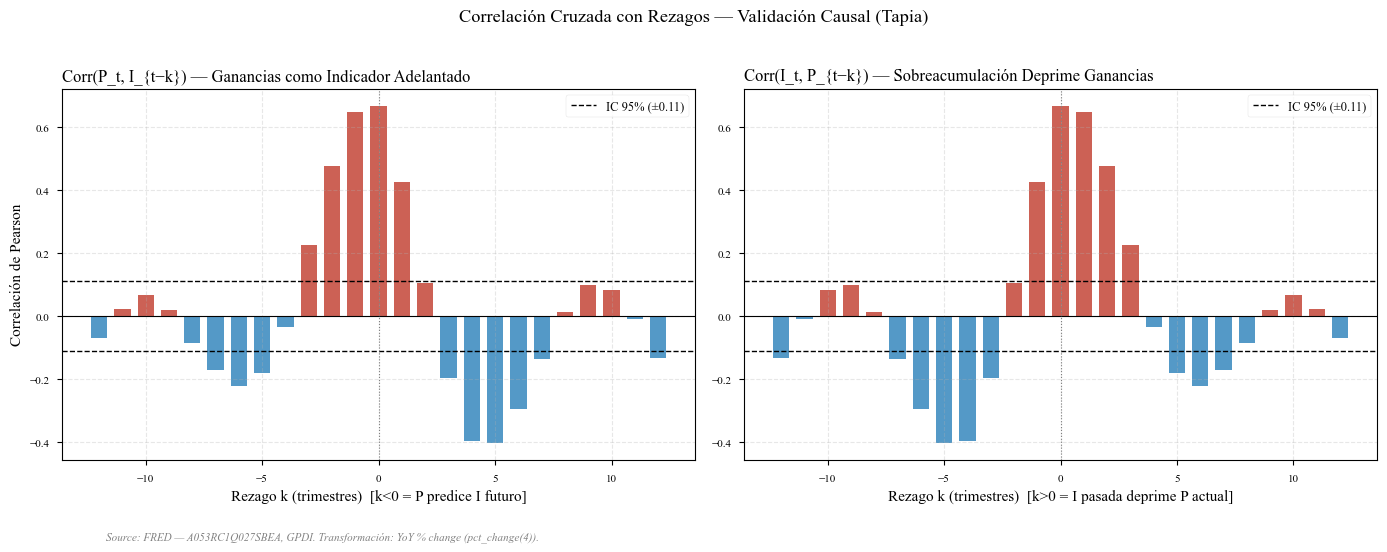

In [5]:
ci = 1.96 / np.sqrt(len(df))  # 95% confidence band

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Corr(P_t, I_{t-k}) — profits lead investment
# Hypothesis: positive correlation at k<0 (current profits → future investment)
colors_pi = ['#c0392b' if c > 0 else '#2980b9' for c in corrs_pi]
ax1.bar(lags_pi, corrs_pi, color=colors_pi, alpha=0.8, width=0.7)
ax1.axhline(ci, color='black', ls='--', lw=1, label=f'IC 95% (±{ci:.2f})')
ax1.axhline(-ci, color='black', ls='--', lw=1)
ax1.axhline(0, color='black', lw=0.8)
ax1.axvline(0, color='gray', lw=0.8, ls=':')
ax1.set_title('Corr(P_t, I_{t−k}) — Ganancias como Indicador Adelantado', loc='left')
ax1.set_xlabel('Rezago k (trimestres)  [k<0 = P predice I futuro]')
ax1.set_ylabel('Correlación de Pearson')
ax1.legend(fontsize=9)

# Panel B: Corr(I_t, P_{t-k}) — past investment suppresses profits
# Hypothesis: negative correlation at k>0 (past investment → lower current profits)
colors_ip = ['#c0392b' if c > 0 else '#2980b9' for c in corrs_ip]
ax2.bar(lags_ip, corrs_ip, color=colors_ip, alpha=0.8, width=0.7)
ax2.axhline(ci, color='black', ls='--', lw=1, label=f'IC 95% (±{ci:.2f})')
ax2.axhline(-ci, color='black', ls='--', lw=1)
ax2.axhline(0, color='black', lw=0.8)
ax2.axvline(0, color='gray', lw=0.8, ls=':')
ax2.set_title('Corr(I_t, P_{t−k}) — Sobreacumulación Deprime Ganancias', loc='left')
ax2.set_xlabel('Rezago k (trimestres)  [k>0 = I pasada deprime P actual]')
ax2.legend(fontsize=9)

fig.suptitle('Correlación Cruzada con Rezagos — Validación Causal (Tapia)', y=1.02)
fig.text(0.08, -0.04,
         'Source: FRED — A053RC1Q027SBEA, GPDI. Transformación: YoY % change (pct_change(4)).',
         fontsize=8, color='gray', style='italic')
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(OUT_DIR / '02_ccf_global.png', dpi=300, bbox_inches='tight')
plt.show()

## Rezagos Segmentados: Expansión vs Recesión

¿La estructura causal cambia entre fases del ciclo? Computa Corr(P_t, I_{t-k}) separadamente.

In [6]:
LAGS_SEG = list(range(0, MAX_LAG + 1))

df_exp = df[df['RECESSION'] < 0.5]
df_rec = df[df['RECESSION'] > 0.5]

print(f"Expansión: {len(df_exp)} obs | Recesión: {len(df_rec)} obs")

# Corr(P_t, I_{t-k}) by phase
corr_exp = [df_exp['PROFITS_YOY'].corr(df_exp['INVEST_YOY'].shift(k)) for k in LAGS_SEG]
corr_rec = [df_rec['PROFITS_YOY'].corr(df_rec['INVEST_YOY'].shift(k)) for k in LAGS_SEG]

Expansión: 271 obs | Recesión: 42 obs


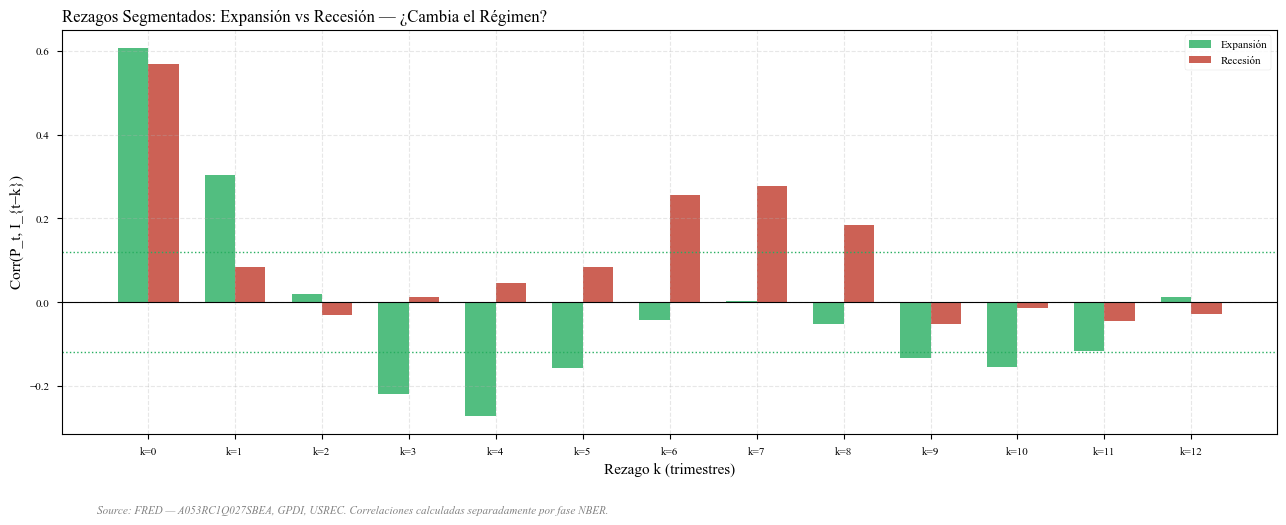

In [7]:
x = np.arange(len(LAGS_SEG))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width/2, corr_exp, width, label='Expansión', color='#27ae60', alpha=0.8)
ax.bar(x + width/2, corr_rec, width, label='Recesión', color='#c0392b', alpha=0.8)

ci_exp = 1.96 / np.sqrt(len(df_exp))
ax.axhline(ci_exp, color='#27ae60', ls=':', lw=1)
ax.axhline(-ci_exp, color='#27ae60', ls=':', lw=1)
ax.axhline(0, color='black', lw=0.8)

ax.set_xticks(x)
ax.set_xticklabels([f'k={k}' for k in LAGS_SEG])
ax.set_xlabel('Rezago k (trimestres)')
ax.set_ylabel('Corr(P_t, I_{t−k})')
ax.set_title('Rezagos Segmentados: Expansión vs Recesión — ¿Cambia el Régimen?', loc='left')
ax.legend()

fig.text(0.08, -0.04,
         'Source: FRED — A053RC1Q027SBEA, GPDI, USREC. Correlaciones calculadas separadamente por fase NBER.',
         fontsize=8, color='gray', style='italic')
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(OUT_DIR / '02_ccf_segmentado.png', dpi=300, bbox_inches='tight')
plt.show()

## Resumen: Lag óptimo

In [8]:
ccf_df = pd.DataFrame({
    'lag': lags_pi,
    'corr_P_I': corrs_pi,   # Corr(P_t, I_{t-k})
    'corr_I_P': corrs_ip    # Corr(I_t, P_{t-k})
})

# k<0: P leads I → find lag where Corr(P_t, I_{t-k}) peaks at negative k
neg_lags = ccf_df[ccf_df['lag'] < 0]
best_lead = neg_lags.loc[neg_lags['corr_P_I'].idxmax(), 'lag']

# k>0: past I suppresses P → find lag where Corr(I_t, P_{t-k}) is most negative
pos_lags = ccf_df[ccf_df['lag'] > 0]
best_suppress = pos_lags.loc[pos_lags['corr_I_P'].idxmin(), 'lag']

print(f"Ganancias lideran inversión: desfase óptimo = {abs(best_lead):.0f} trimestres")
print(f"Inversión pasada deprime ganancias: desfase óptimo = {best_suppress:.0f} trimestres")
print("\nEsto confirma la estructura causal endógena del modelo de Tapia.")

Ganancias lideran inversión: desfase óptimo = 1 trimestres
Inversión pasada deprime ganancias: desfase óptimo = 6 trimestres

Esto confirma la estructura causal endógena del modelo de Tapia.
